### Report Maciej Janicki, Wojciech Bogacz

In [95]:
import numpy as np
import glob
import sklearn
import matplotlib.pyplot as plt
import cvxopt
cvxopt.solvers.options['show_progress'] = False
import ipywidgets as widgets
from ipywidgets import interact
from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function

In [96]:
def load_stock_data(filename):
    with open(filename, "r") as file:
        name : str
        n : int
        datapoints = []
        for i, line in enumerate(file):
            line = line.strip()
            if i == 0:
                name = line
            elif i == 1:
                n = int(line)
            else:
                _, point = line.split(" ")
                point = float(point)
                datapoints.append(point)
        assert(len(datapoints) == n)
        return name, np.array(datapoints)

In [97]:
stocks = {}
for stock_filename in glob.glob("bundle2/*.txt"):
    name, datapoints = load_stock_data(stock_filename)
    stocks[name] = datapoints

In [98]:
# def linear_regression_prediction(datapoints, n_past_samples):
#     x = np.arange(n_past_samples,len(datapoints)).reshape(-1, 1)
#     print(x)
#     reg = sklearn.linear_model.LinearRegression().fit(x, datapoints[n_past_samples:])
#     err = np.std(datapoints[n_past_samples:] - reg.predict(x))
#     px = np.arange(len(datapoints), len(datapoints) + 100).reshape(-1, 1) # go to next T
#     return np.clip(reg.predict(px), a_min=err, a_max=np.inf), err

def create_harmonic_elements(x, harmonic_order, period_len):
    intercept = np.ones_like(x)
    components = [intercept, x]
    for order in range(1, harmonic_order+1):
        zx = 2 * np.pi * order * x / period_len
        comp = np.sin(zx) + np.cos(zx)
        components.append(comp)
    components = np.column_stack(components)
    return components
    

def harmonic_regression_prediction(datapoints, harmonic_order, period_len):
    x = create_harmonic_elements(np.arange(len(datapoints)), harmonic_order, period_len)
    reg = sklearn.linear_model.BayesianRidge().fit(x, np.log(datapoints))
    err = np.std(datapoints - np.exp(reg.predict(x)))

    px = create_harmonic_elements(np.arange(len(datapoints), len(datapoints) + 100), harmonic_order, period_len) # go to next T
    return np.exp(reg.predict(px)), err

def symbolic_regression_prediciton(datapoints):
    regressor = SymbolicRegressor(
        population_size=2000,
        generations=50,
        function_set=('add', 'sub', 'mul', 'div', 'sin', 'cos'),
        stopping_criteria=1e-4,
        p_crossover=0.7,
        p_subtree_mutation=0.1,
        p_hoist_mutation=0.05,
        p_point_mutation=0.15,
        max_samples=1.0,
        # parsimony_coefficient=0.0005,
        random_state=0,
        # verbose=1
    )
    x = np.arange(len(datapoints)).reshape(-1, 1)
    mean = np.mean(datapoints)
    regressor.fit(x,  datapoints-mean)
    err = np.std(datapoints - regressor.predict(x))
    px = np.arange(len(datapoints), len(datapoints) + 100).reshape(-1, 1) # go to next T
    print(regressor._program)
    return regressor.predict(px) + mean, err






In [99]:
stocks_predicted_ratios = {} # predictions for last day only
harmonic_order=35
period_len=301
stock_predicted_values = {}
for stock_name, stock_datapoints in stocks.items():
    predictions, err = symbolic_regression_prediciton(stock_datapoints)
    
    stocks_predicted_ratios[stock_name] = predictions[-1] / stock_datapoints[-1]
    x = np.arange(len(stock_datapoints))
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + 100)
    stock_predicted_values[stock_name] = predictions


sub(mul(0.385, sin(mul(add(-0.680, add(-0.680, add(-0.680, sub(add(sub(X0, -0.229), mul(0.926, -0.841)), sin(add(X0, X0)))))), -0.130))), div(sin(mul(X0, -0.119)), mul(X0, -0.105)))
cos(add(add(mul(-0.039, X0), cos(add(mul(-0.039, X0), sin(add(mul(-0.040, X0), cos(cos(cos(cos(mul(-0.040, X0)))))))))), cos(sin(sub(add(mul(-0.040, X0), mul(-0.040, X0)), 0.142)))))
sin(mul(add(X0, 0.438), sub(0.955, 0.987)))
add(mul(-0.024, mul(0.121, X0)), sin(div(sin(add(0.694, mul(0.019, X0))), 0.616)))
sin(sin(cos(sub(mul(X0, -0.077), 0.561))))
div(sin(div(sin(mul(mul(-0.848, 0.043), sub(cos(mul(-0.035, X0)), sub(X0, cos(mul(-0.035, X0)))))), 0.548)), cos(-0.852))
div(add(0.342, mul(-0.004, X0)), 0.457)
sin(mul(sub(mul(-0.536, X0), mul(0.532, X0)), sub(0.104, cos(sub(-0.868, 0.630)))))
add(cos(mul(X0, -0.013)), sin(add(sin(sin(sin(add(cos(mul(X0, div(-0.013, -0.526))), cos(mul(X0, div(-0.013, -0.584))))))), sin(sin(sin(sin(sin(sin(sin(cos(mul(X0, div(0.055, 0.595)))))))))))))
add(cos(mul(X0, div(-0.01

In [100]:
m = []
stocks_expected_return = []
for stock in stocks:
    m.append(stocks[stock])
    stocks_expected_return.append(stocks_predicted_ratios[stock])
m = np.array(m)
stocks_covariance = np.cov(m)
stocks_expected_return = np.array(stocks_expected_return) - 1

In [101]:
def evaluate_solution(weights, expected_return, covariance_matrix):
    return np.sum(weights * (expected_return)), weights.T @ covariance_matrix @ weights

def wsm_solve(risk_weight, expected_return, covariance_matrix, normalize = True):
    n_factor_risk = 1.0
    n_factor_return = 1.0
    if normalize:
        wreturn = wsm_solve(0.0, expected_return, covariance_matrix, normalize=False)
        wrisk = wsm_solve(1.0, expected_return, covariance_matrix, normalize=False)
        max_return, max_risk = evaluate_solution(wreturn, expected_return, covariance_matrix)
        min_return, min_risk = evaluate_solution(wrisk, expected_return, covariance_matrix)
        n_factor_return = 1 / (max_return - min_return)
        n_factor_risk = 1 / (max_risk - min_risk)
    n = len(expected_return)
    Q = cvxopt.matrix(2 * risk_weight * n_factor_risk * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix((1 - risk_weight) * expected_return * -1 * n_factor_return)
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(-np.eye(n))
    h = cvxopt.matrix(np.zeros(n))

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights



### Report
Maciej Janicki 156073
Wojciech Bogacz 156034

To select our portfolio for the portfolio game, we estimated future stock prices using symbolic regression (results presented below) and calculated risk using Markowitz's model. We generated Pareto fronts by solving a quadratic programming problem using the Weighted Sum Method (WSM) and the Epsilon-Constrained Method (ECM).

For the final weights, we selected a solution from the ECM set of Pareto solutions with a maximum risk of 0.015. This solution was subsequently modified to ensure a minimum allocation of 1% to each stock. To normalize the weights, for every stock where we increased the allocation from 0% to 1%, we subtracted 1 percentage point from the most heavily weighted stock. This adjustment was made to increase the overall diversification of our investment.

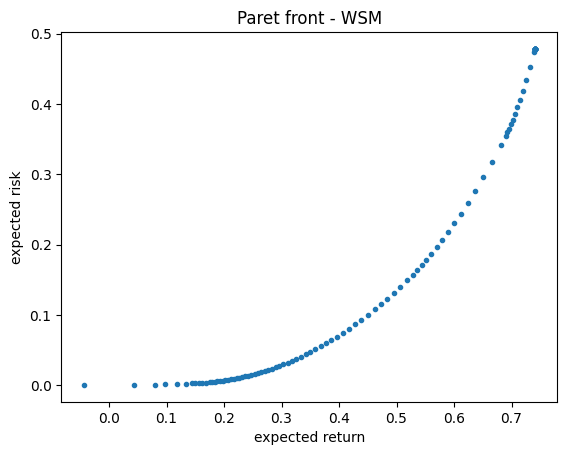

In [102]:
n_samples = 100
wsm_x_returns = []
wsm_y_risks = []
wsm_solutions = []
for i in range(n_samples + 1):
    wcm_weight = 1 / n_samples * i
    w = wsm_solve(wcm_weight, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    wsm_x_returns.append(ereturn)
    wsm_y_risks.append(risk)
    wsm_solutions.append(w)
wsm_x_returns = np.array(wsm_x_returns)

plt.scatter(wsm_x_returns, wsm_y_risks, marker=".")
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title("Paret front - WSM")
plt.show()

In [103]:
def ecm_solve(epsilon, expected_return, covariance_matrix):
    n = len(expected_return)
    Q = cvxopt.matrix(2 * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix(np.zeros(n))
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(np.vstack((-expected_return,-np.eye(n))))
    h = np.zeros(n+1)
    h[0] = -epsilon
    h = cvxopt.matrix(h)

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights

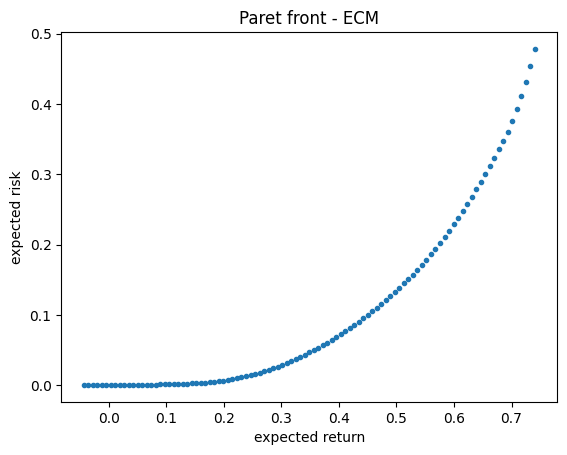

In [104]:
threshold_step = (np.max(wsm_x_returns)-np.min(wsm_x_returns))/n_samples
ecm_x_returns = []
ecm_y_risks = []
ecm_solutions = []
for i in range(n_samples + 1):
    t = i * threshold_step + np.min(wsm_x_returns)
    w = ecm_solve(t, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    ecm_x_returns.append(ereturn)
    ecm_y_risks.append(risk)
    ecm_solutions.append(w)
plt.scatter(ecm_x_returns, ecm_y_risks, marker=".")
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title("Paret front - ECM")
plt.show()


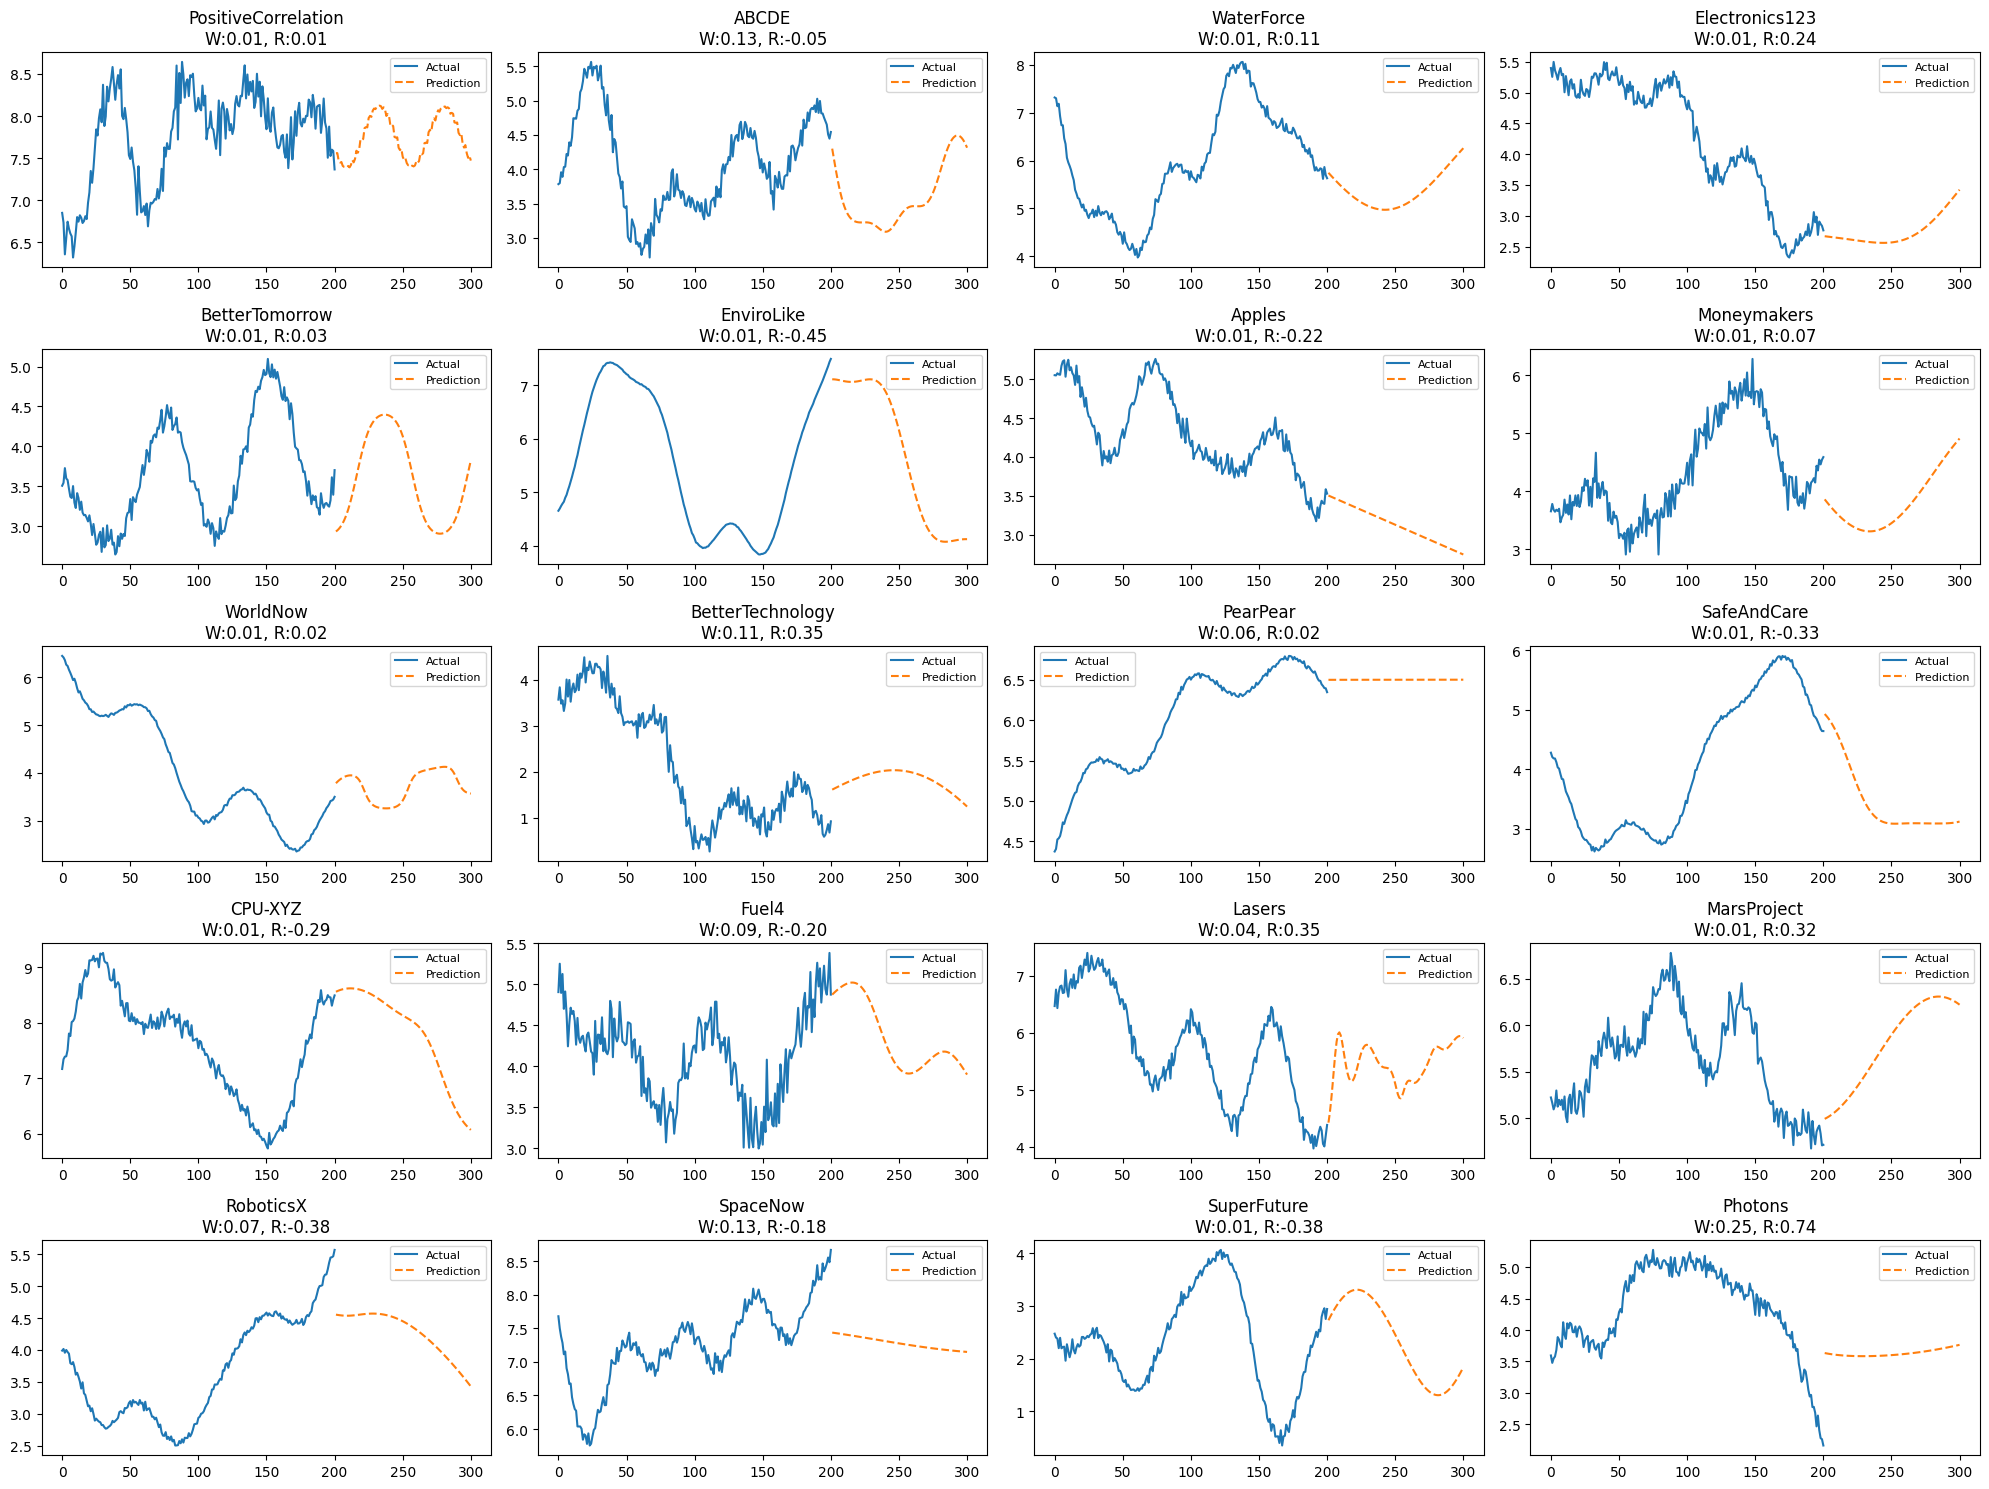

In [105]:
chosen_weights = None
max_risk = 0.015
for i, ret in enumerate(ecm_y_risks):
    if ret >= max_risk:
        chosen_weights = ecm_solutions[i]
        break

for i in range(len(chosen_weights)):
    if chosen_weights[i] <= 0.0001:
        chosen_weights[i] = 0.01
        chosen_weights[np.argmax(chosen_weights)] -= 0.01

ereturn, erisk = evaluate_solution(chosen_weights, stocks_expected_return, stocks_covariance)


n_stocks = len(stocks)
cols = 4
rows = int(np.ceil(n_stocks / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
axes = axes.flatten()  # makes indexing easy

for i, key in enumerate(stocks):
    ax = axes[i]
    
    stock_datapoints = stocks[key]
    x = np.arange(len(stock_datapoints))
    
    # Actual data
    ax.plot(x, stock_datapoints, label="Actual")
    
    # Predictions
    predictions = stock_predicted_values[key]
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + len(predictions))
    ax.plot(px, predictions, linestyle="--", label="Prediction")
    
    # Title
    ax.set_title(
        f"{key}\nW:{chosen_weights[i]:.2f}, R:{stocks_predicted_ratios[key] - 1:.2f}"
    )
    
    ax.legend(fontsize=8)

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [110]:
assert np.sum(chosen_weights) - 1.0 < 1e-9

stock_chosen_weights = {}
for i, stock in enumerate(stocks):
    stock_chosen_weights[stock] = chosen_weights[i]


stocks_order = ["SuperFuture",
    "Apples",
    "WorldNow",
    "Electronics123",
    "Photons",
    "SpaceNow",
    "PearPear",
    "PositiveCorrelation",
    "BetterTechnology",
    "ABCDE",
    "EnviroLike",
    "Moneymakers",
    "Fuel4",
    "MarsProject",
    "CPU-XYZ",
    "RoboticsX",
    "Lasers",
    "WaterForce",
    "SafeAndCare",
    "BetterTomorrow",]

correct_weight_order = [str(ereturn), str(erisk)]
for stock in stocks_order :
    correct_weight_order.append(str(stock_chosen_weights[stock]))
with open("156073_156034.txt", "w") as file:
    file.write(" ".join(correct_weight_order))
